## IMPORTING LIBRARIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## IMPORTING DATASET

In [2]:
df=pd.read_csv(r"C:\Users\Aditya Singh\Downloads\archive (5)\StudentsPerformance.csv")

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 103.5 KB


In [8]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
df["average_score"] = (
df["math score"]
+ df["reading score"]
+ df["writing score"]
)/3

In [10]:
bins=(0,40,60,80,100)
label = ( "Needs Improvement ","Satisfactory","Good","Excellent")
df["performance_category"]=pd.cut(df["average_score"],bins=bins,labels=label)

In [11]:
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,performance_category
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,Good
1,female,group C,some college,standard,completed,69,90,88,82.333333,Excellent
2,female,group B,master's degree,standard,none,90,95,93,92.666667,Excellent
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,Satisfactory
4,male,group C,some college,standard,none,76,78,75,76.333333,Good
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,94.000000,Excellent
996,male,group C,high school,free/reduced,none,62,55,55,57.333333,Satisfactory
997,female,group C,high school,free/reduced,completed,59,71,65,65.000000,Good
998,female,group D,some college,standard,completed,68,78,77,74.333333,Good


## GENDER PERFORMANCE

In [12]:
gender_analysis = df.groupby("gender")[
    ["math score",
     "reading score",
     "writing score",
     "average_score"]
].mean()

In [13]:
gender_analysis

,math score,reading score,writing score,average_score
gender,,,,
female,63.633205,72.608108,72.467181,69.569498
male,68.728216,65.473029,63.311203,65.837483


## TEST PREP IMPACT

In [14]:
df.groupby("test preparation course")["average_score"].mean()

test preparation course
completed    72.669460
none         65.038941
Name: average_score, dtype: float64

## PARENT EDUCATION IMPACT 

In [15]:
df.groupby(
"parental level of education"
)["average_score"].mean().sort_values()

parental level of education
high school           63.096939
some high school      65.108007
some college          68.476401
associate's degree    69.569069
bachelor's degree     71.923729
master's degree       73.598870
Name: average_score, dtype: float64

<Axes: xlabel='parental level of education', ylabel='average_score'>

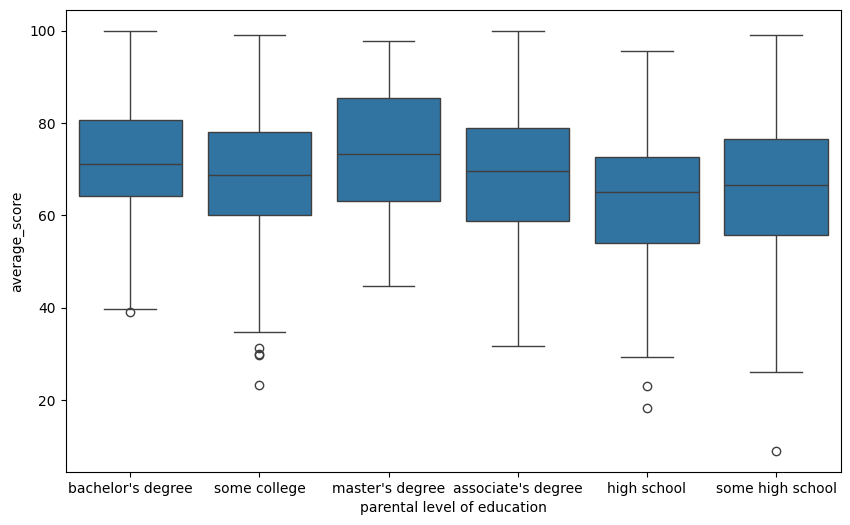

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="parental level of education",y="average_score")

# Race/Ethnicity Analysis

In [17]:
df.groupby(
    "race/ethnicity"
)["average_score"].mean()

race/ethnicity
group A    62.992509
group B    65.468421
group C    67.131661
group D    69.179389
group E    72.752381
Name: average_score, dtype: float64

## DISTRIBUTION OF SCORES

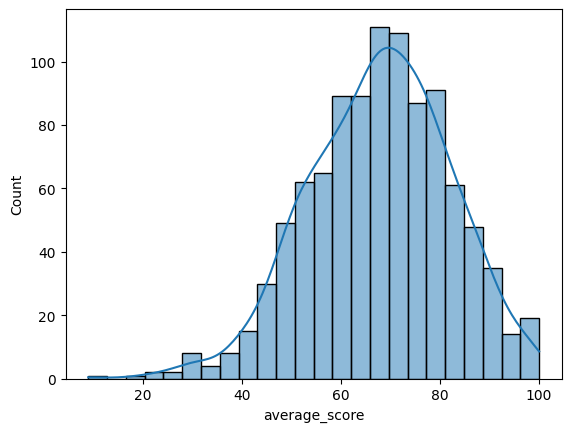

In [18]:
sns.histplot(df["average_score"],kde=True)
plt.show()

## GENDER WISE SCORES

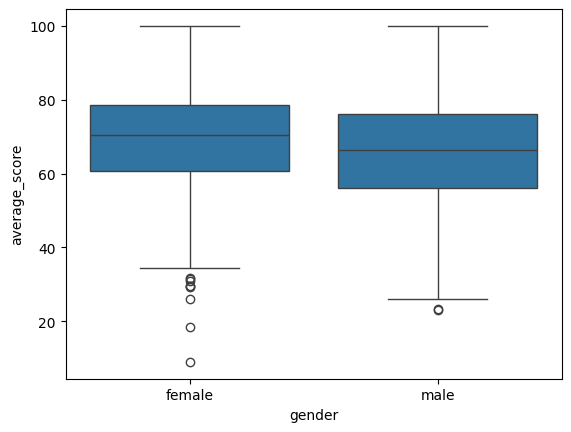

In [19]:
sns.boxplot(x='gender',y='average_score',data=df) 
plt.show()

In [20]:
gender_analysis = df.groupby(
    "gender"
)[ [ "math score","reading score", "writing score"]].mean()

gender_analysis

,math score,reading score,writing score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


<Axes: xlabel='gender'>

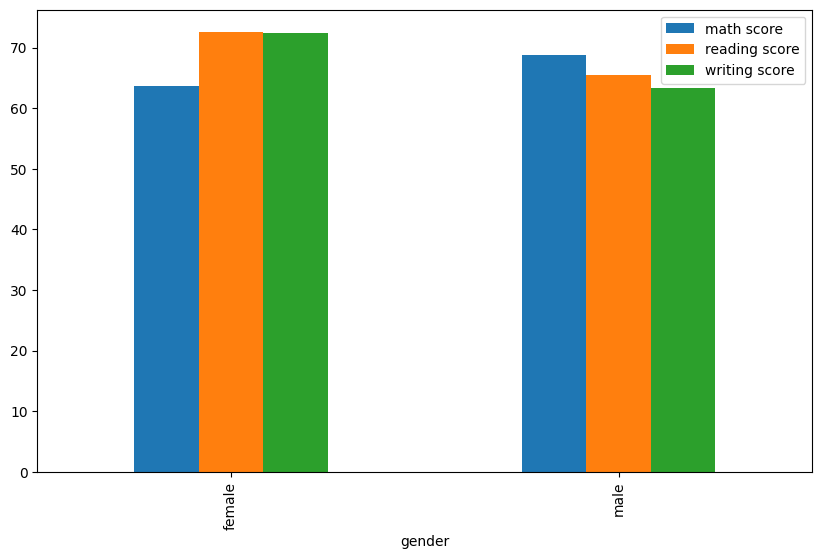

In [21]:
gender_analysis.plot(kind="bar",figsize=(10,6))

# LUNCH WISE AVERAGE SCORES

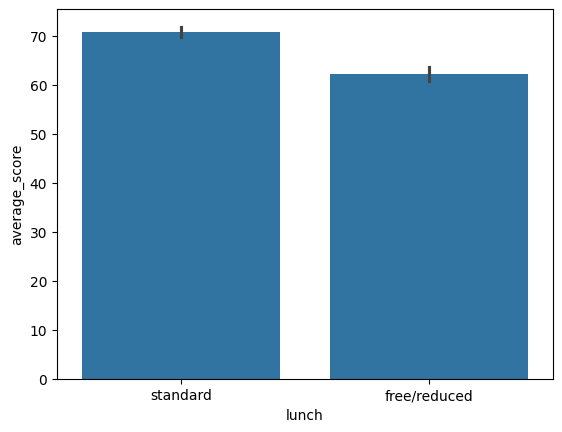

In [22]:
sns.barplot(
x="lunch",
y="average_score",
data=df
)
plt.show()

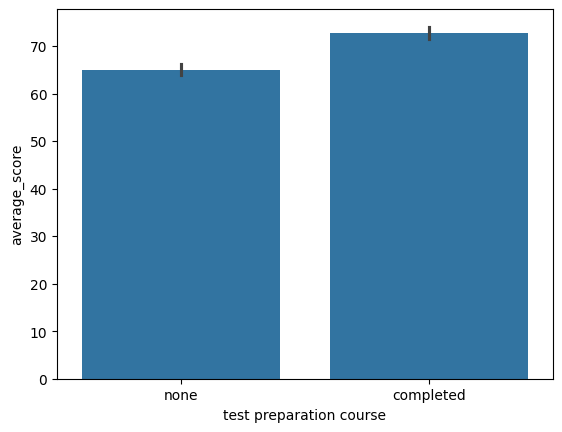

In [23]:
sns.barplot(
x="test preparation course",
y="average_score",
data=df
)
plt.show()

## CORRELATION HEATMAP

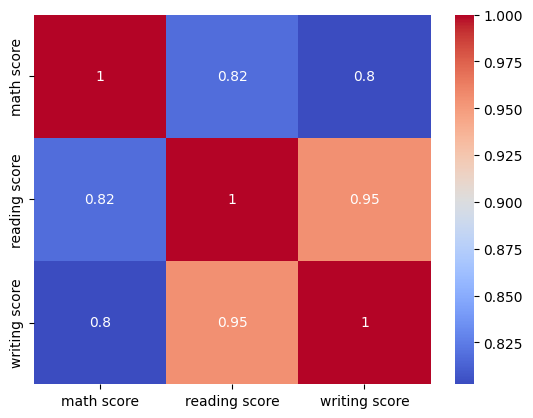

In [24]:
corr=df[['math score','reading score','writing score']].corr()
sns.heatmap(corr,annot=True,cmap="coolwarm") 
plt.show()

# SUBJECT WISE COMPARISON

<Figure size 800x500 with 0 Axes>

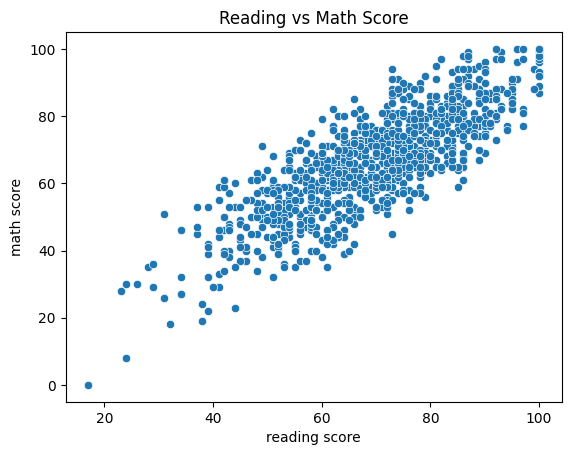

<Figure size 800x500 with 0 Axes>

In [25]:
plt.title("Reading vs Math Score")
sns.scatterplot(data=df,x="reading score",y="math score")
plt.figure(figsize=(8,5))

# AT RISK GROUPS

In [26]:
df["At_Risk"] = np.where(
    (df["math score"] < 50) |
    (df["reading score"] < 50) |
    (df["writing score"] < 50),
    "Yes",
    "No"
)

In [27]:
df["At_Risk"].value_counts()

At_Risk
No     812
Yes    188
Name: count, dtype: int64

In [28]:
risk_group = (
df.groupby("race/ethnicity")
["At_Risk"]
.apply(
lambda x:
(x=="Yes").mean()*100
)
.sort_values(
ascending=False
)
)

Text(0.5, 1.0, 'At Risk Group')

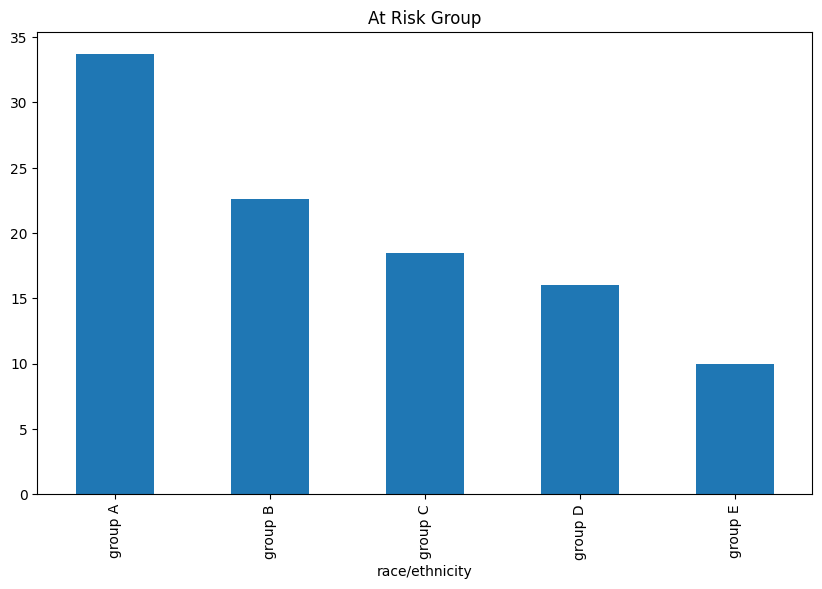

In [29]:
risk_group.plot(kind="bar",figsize=(10,6))
plt.title("At Risk Group")

# Principal's Report

## Executive Summary

This analysis examined student performance to identify factors that affect academic scores and determine at-risk students. The results show that parental education and test preparation have a positive impact on performance. Several students were identified as at-risk and may benefit from additional academic support.

## Key Findings

1. Students who completed the test preparation course scored higher on average.
2. Reading and writing scores showed a strong positive correlation.
3. Students with highly educated parents generally performed better.
4. Female students performed better in reading and writing, while male students performed slightly better in mathematics.
5. A significant number of students were identified as at-risk based on low scores in one or more subjects.

## Recommendations

1. Increase participation in test preparation programs.
2. Provide extra support and mentoring for at-risk students.
3. Encourage greater parental involvement in student learning.

## Conclusion

Student performance is influenced by both academic preparation and family background. Focused support programs and early intervention can help improve overall student outcomes and reduce the number of at-risk students.


## Most Impactful Recommendation

The most impactful recommendation is expanding test preparation programs. Students who completed the program achieved higher scores across subjects. Increasing access to these programs can improve overall academic performance and help more students succeed.
